In [1]:
import tensorflow
import numpy as np
import keras
import cv2,os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from glob import glob
from itertools import chain
from datetime import datetime
import statistics

from tqdm import tqdm

from sklearn.model_selection import train_test_split


2025-09-23 02:02:22.994494: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-09-23 02:02:22.994679: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-23 02:02:23.141248: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Data Preprocessing

In [2]:
data_path='/kaggle/input/annotated-dataset-for-knee-arthritis-detection/Training'
categories=os.listdir(data_path)
labels=[i for i in range(len(categories))]

label_dict=dict(zip(categories,labels)) #empty dictionary
print(label_dict)
print(categories)
print(labels)

{'1Doubtful': 0, '3Moderate': 1, '4Severe': 2, '2Mild': 3, '0Normal': 4}
['1Doubtful', '3Moderate', '4Severe', '2Mild', '0Normal']
[0, 1, 2, 3, 4]


In [4]:
!pip install split-folders

import splitfolders

splitfolders.ratio(
    "/kaggle/input/annotated-dataset-for-knee-arthritis-detection/Training",
    output="/kaggle/working/New_Dataset",
    seed=1345,
    ratio=(0.8, 0.1, 0.1)
)


/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Copying files: 1650 files [00:08, 197.94 files/s]


In [5]:
import os
print(os.listdir("/kaggle/working/New_Dataset"))
print(os.listdir("/kaggle/working/New_Dataset/train"))
for cls in os.listdir("/kaggle/working/New_Dataset/train"):
    path = f"/kaggle/working/New_Dataset/train/{cls}"
    print(cls, ":", len(os.listdir(path)))


['test', 'val', 'train']
['2Mild', '4Severe', '3Moderate', '0Normal', '1Doubtful']
2Mild : 185
4Severe : 164
3Moderate : 176
0Normal : 411
1Doubtful : 381


In [6]:
import tensorflow as tf
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32
train_dir = "/kaggle/working/New_Dataset/train"
val_dir = "/kaggle/working/New_Dataset/val"
test_dir = "/kaggle/working/New_Dataset/test"
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)


Found 1317 files belonging to 5 classes.
Found 163 files belonging to 5 classes.
Found 170 files belonging to 5 classes.


In [7]:
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)
y_true


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4], dtype=int32)

In [8]:
import tensorflow as tf
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

IMG_SIZE = 128
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
BATCH_SIZE = 32
EPOCHS = 50
train_dir = "/kaggle/working/New_Dataset/train"
val_dir = "/kaggle/working/New_Dataset/val"
test_dir = "/kaggle/working/New_Dataset/test"

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False)

y_train = np.concatenate([y.numpy() for x, y in train_ds], axis=0)
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, class_weights))
print("Class weights:", class_weights_dict)

base_model = tf.keras.applications.Xception(
    weights="imagenet",
    input_shape=IMG_SHAPE,
    include_top=False
)
base_model.trainable = True

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(classes), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

def get_callbacks(model_name):
    callbacks = []
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        filepath=f"{model_name}.keras",
        monitor='val_loss',
        verbose=1,
        save_best_only=True,
        mode='min'
    )
    callbacks.append(checkpoint)

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1,
        mode='min',
        min_lr=1e-6
    )
    callbacks.append(reduce_lr)

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        verbose=1,
        restore_best_weights=True
    )
    callbacks.append(early_stop)
    return callbacks

callbacks = get_callbacks('Xception_ClassWeighted')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights_dict
)


Found 1317 files belonging to 5 classes.
Found 163 files belonging to 5 classes.
Found 170 files belonging to 5 classes.
Class weights: {0: 0.6408759124087591, 1: 0.6913385826771653, 2: 1.4237837837837837, 3: 1.496590909090909, 4: 1.6060975609756099}
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
 1/42 ━━━━━━━━━━━━━━━━━━━━ 37:16 55s/step - accuracy: 0.3438 - loss: 1.7771

I0000 00:00:1758593123.293331     115 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 682ms/step - accuracy: 0.3542 - loss: 1.5463
Epoch 1: val_loss improved from inf to 11.74581, saving model to Xception_ClassWeighted.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 91s 887ms/step - accuracy: 0.3558 - loss: 1.5427 - val_accuracy: 0.2638 - val_loss: 11.7458 - learning_rate: 0.0010
Epoch 2/50
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5870 - loss: 1.0569
Epoch 2: val_loss did not improve from 11.74581
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.5879 - loss: 1.0566 - val_accuracy: 0.3681 - val_loss: 25.0942 - learning_rate: 0.0010
Epoch 3/50
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.6950 - loss: 0.8261
Epoch 3: val_loss did not improve from 11.74581
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.6962 - loss: 0.8237 - val_accuracy: 0.4601 - val_loss: 50.7099 - learning_rate: 0.0010
Epoch 4/50
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.7518 - loss: 0.6957
Epoch 4: val_loss improved from 11.74581 to 1.6141

In [9]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 4, 4, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,630,345 (250.36 MB)

 Trainable params: 21,858,605 (83.38 MB)

 Non-trainable params: 54,528 (213.00 KB)

 Optimizer params: 43,717,212 (166.77 MB)

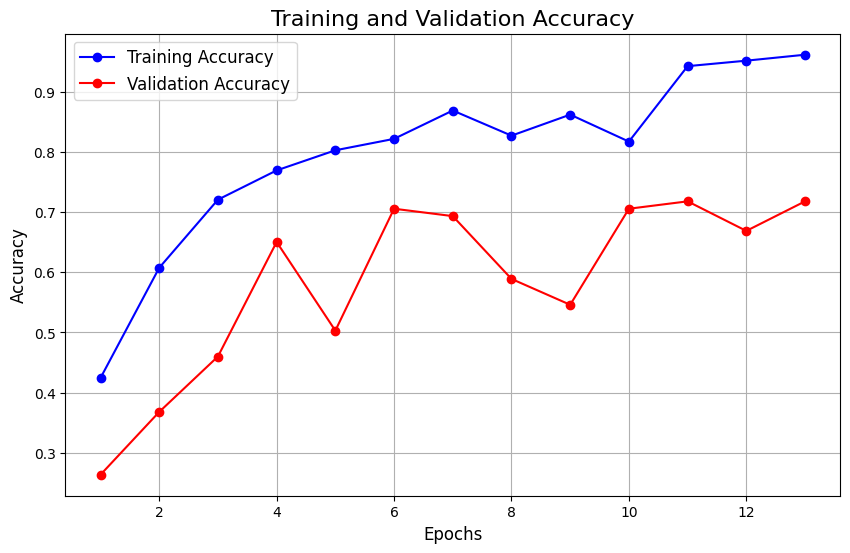

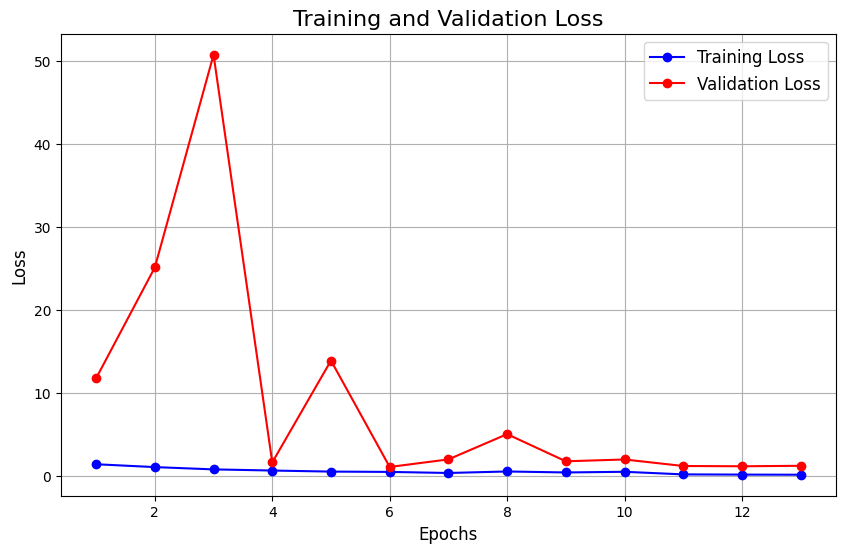

In [10]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)
plt.figure(figsize=(10,6))
plt.plot(epochs, acc, 'b-o', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-o', label='Validation Accuracy')
plt.title('Training and Validation Accuracy', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True)
plt.legend(fontsize=12)
plt.show()
plt.figure(figsize=(10,6))
plt.plot(epochs, loss, 'b-o', label='Training Loss')
plt.plot(epochs, val_loss, 'r-o', label='Validation Loss')
plt.title('Training and Validation Loss', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True)
plt.legend(fontsize=12)
plt.show()


In [12]:
from sklearn.metrics import classification_report
import numpy as np
y_pred = model.predict(test_ds)
predicted_categories = np.argmax(y_pred, axis=1)
true_categories = y_true
print(classification_report(true_categories, predicted_categories, digits=4))


6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 969ms/step
              precision    recall  f1-score   support

           0     0.8302    0.8462    0.8381        52
           1     0.7500    0.6735    0.7097        49
           2     0.5238    0.4583    0.4889        24
           3     0.7500    0.9130    0.8235        23
           4     0.8333    0.9091    0.8696        22

    accuracy                         0.7588       170
   macro avg     0.7375    0.7600    0.7460       170
weighted avg     0.7534    0.7588    0.7539       170



In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report
import numpy as np
img_height = 128   
img_width = 128
batch_size = 32
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)
train_dir = "/kaggle/working/New_Dataset/train"
val_dir   = "/kaggle/working/New_Dataset/val"
test_dir  = "/kaggle/working/New_Dataset/test"

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'  
)

validation_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    callbacks=[early_stopping, reduce_lr]
)

y_pred = model.predict(test_generator)
predicted_classes = np.argmax(y_pred, axis=1)
true_classes = test_generator.classes

print(classification_report(true_classes, predicted_classes, digits=4))


Found 1317 images belonging to 5 classes.
Found 163 images belonging to 5 classes.
Found 170 images belonging to 5 classes.
Epoch 1/50


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


42/42 ━━━━━━━━━━━━━━━━━━━━ 79s 802ms/step - accuracy: 0.5855 - loss: 1.0179 - val_accuracy: 0.3129 - val_loss: 17.7526 - learning_rate: 0.0010
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 192ms/step - accuracy: 0.6445 - loss: 0.9459 - val_accuracy: 0.3129 - val_loss: 16.8071 - learning_rate: 0.0010
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 187ms/step - accuracy: 0.6926 - loss: 0.7837 - val_accuracy: 0.3129 - val_loss: 30.6184 - learning_rate: 0.0010
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 187ms/step - accuracy: 0.7206 - loss: 0.8035 - val_accuracy: 0.3129 - val_loss: 11.7974 - learning_rate: 0.0010
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 196ms/step - accuracy: 0.7372 - loss: 0.6860 - val_accuracy: 0.3129 - val_loss: 6.6878 - learning_rate: 0.0010
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 194ms/step - accuracy: 0.7574 - loss: 0.6989 - val_accuracy: 0.3129 - val_loss: 4.6744 - learning_rate: 0.0010
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 193ms/step - accuracy: 0.7804 - loss: 0.6185 - val_

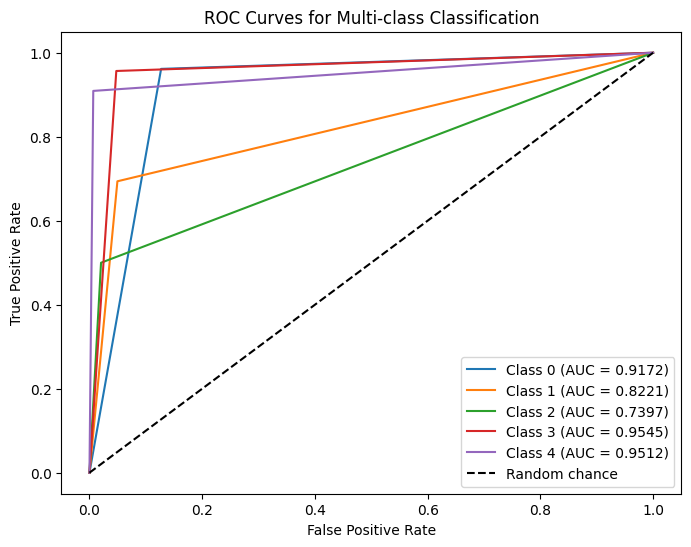

In [19]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
y_true_bin = label_binarize(true_classes, classes=np.unique(true_classes))
y_pred_bin = label_binarize(predicted_classes, classes=np.unique(true_classes))

n_classes = y_true_bin.shape[1]
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:0.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Multi-class Classification')
plt.legend(loc='lower right')
plt.show()
